In [24]:
# CRIM: crime rate
# ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
# INDUS: proportion of non-retail business acres per town
# CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
# NOX: nitric oxides concentration (parts per 10 million) 1https://archive.ics.uci.edu/ml/datasets/Housing 123 20.2. Load the Dataset 124
# RM: average number of rooms per dwelling
# AGE: proportion of owner-occupied units built prior to 1940
# DIS: weighted distances to ﬁve Boston employment centers
# RAD: index of accessibility to radial highways
# TAX: full-value property-tax rate per $10,000
# PTRATIO: pupil-teacher ratio by town 12. 
# B: 1000(Bk−0.63)2 where Bk is the proportion of blacks by town 13. 
# LSTAT: % lower status of the population
# MEDV: Median value of owner-occupied homes in $1000s We can see that the input attributes have a mixture of units.

In [2]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

df_1=pd.read_csv("/kaggle/input/boston-house-prices/housing.csv")
df_1.head()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


In [27]:
df_1.shape

(505, 1)

In [4]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv("/kaggle/input/boston-house-prices/housing.csv", header=None, delimiter=r"\s+", names=column_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.shape

(506, 14)

In [5]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Tope 10 features by correlation with MEDV: 
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


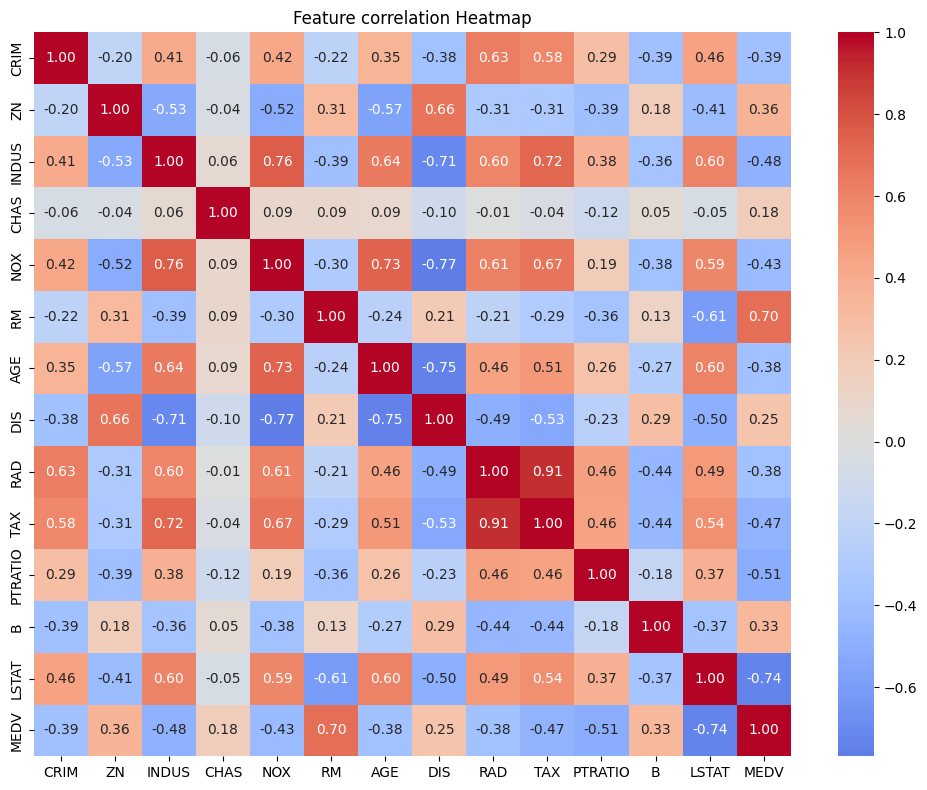

In [8]:
#Correlation analysis of MEDV with other features
corr = df.corr()['MEDV'].sort_values(ascending=False)
print("Tope 10 features by correlation with MEDV: ")
print(corr)

# Heatmap visualization
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Feature correlation Heatmap")
plt.tight_layout()
plt.show()

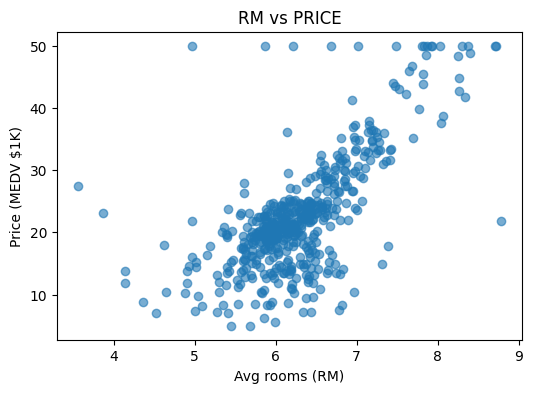

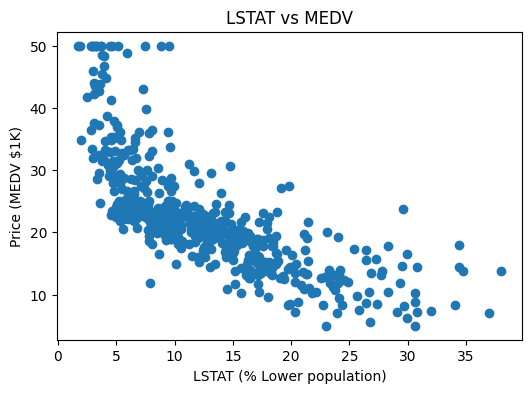

In [53]:
# 2 features correlated with MEDV are: RM, LSTAT
#EDA for RM
plt.figure(figsize=(6,4))
plt.scatter(df['RM'], df['MEDV'], alpha=0.6)
plt.xlabel("Avg rooms (RM)")
plt.ylabel("Price (MEDV $1K)")
plt.title("RM vs PRICE")
plt.show()

#EDA for LSTAT
plt.figure(figsize=(6,4))
plt.scatter(df['LSTAT'], df['MEDV'])
plt.xlabel("LSTAT (% Lower population)")
plt.ylabel("Price (MEDV $1K)")
plt.title("LSTAT vs MEDV")
plt.show()

In [77]:
X=df.drop('MEDV', axis=1)
# X=df[['RM', 'LSTAT']]
y=df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_l=LinearRegression().fit(X_train, y_train)
y_train_pred_l=reg_l.predict(X_train)
y_test_pred_l=reg_l.predict(X_test)
print("Training accuracy (Linear Regression): ", reg_l.score(X_train, y_train))
print("Test accuracy (Linear Regression): ", reg_l.score(X_test, y_test))
coef_df_l=pd.DataFrame({'Feature': X.columns, "Coef": reg_l.coef_}) # we find coef here to know how much MEDV (target feature) change when this feature increases by 1 unit
print(coef_df_l.sort_values('Coef', ascending=False))
print("Intercept: ", reg_l.intercept_)

print("-----------------------------------------------------------")

#Using ridge now
from sklearn.linear_model import Ridge
reg_r=Ridge(alpha=100).fit(X_train, y_train)
y_train_pred_r=reg_r.predict(X_train)
y_test_pred_r=reg_r.predict(X_test)
print("Training accuracy (Linear Regression): ", reg_r.score(X_train, y_train))
print("Test accuracy (Linear Regression): ", reg_r.score(X_test, y_test))
coef_df_r=pd.DataFrame({'Feature': X.columns, "Coef": reg_r.coef_}) # we find coef here to know how much MEDV (target feature) change when this feature increases by 1 unit
print(coef_df_r.sort_values('Coef', ascending=False))
print("Intercept: ", reg_r.intercept_)

Training accuracy (Linear Regression):  0.7508856358979673
Test accuracy (Linear Regression):  0.6687594935356326
    Feature       Coef
5        RM   4.438835
3      CHAS   2.784438
8       RAD   0.262430
2     INDUS   0.040381
1        ZN   0.030110
11        B   0.012351
6       AGE  -0.006296
9       TAX  -0.010647
0      CRIM  -0.113056
12    LSTAT  -0.508571
10  PTRATIO  -0.915456
7       DIS  -1.447865
4       NOX -17.202633
Intercept:  30.24675099392366
-----------------------------------------------------------
Training accuracy (Linear Regression):  0.7230438194128695
Test accuracy (Linear Regression):  0.6800123820451882
    Feature      Coef
5        RM  2.438815
3      CHAS  0.550702
8       RAD  0.299014
1        ZN  0.039892
11        B  0.011951
6       AGE  0.000545
9       TAX -0.014630
2     INDUS -0.048625
0      CRIM -0.110765
4       NOX -0.197859
12    LSTAT -0.689539
10  PTRATIO -0.817852
7       DIS -1.129400
Intercept:  34.62659588633344


In [101]:
rmse_train_l=np.sqrt(mean_squared_error(y_train, y_train_pred_l))
rmse_test_l=np.sqrt(mean_squared_error(y_test, y_test_pred_l))
r2_train_l=r2_score(y_train, y_train_pred_l)
r2_test_l=r2_score(y_test, y_test_pred_l)
mse_train_l=mean_squared_error(y_train, y_train_pred_l)
mse_test_l=mean_squared_error(y_test, y_test_pred_l)
print('Linear regression results')
print(f"Train RMSE: {rmse_train_l} | Test RMSE: {rmse_test_l}")
print(f"Train R2: {r2_train_l} | Test R2: {r2_test_l}")
print(f"Train MSE: {mse_train_l} | Test MSE: {mse_test_l}")
print("-----------------------------------------------------------------")
rmse_train_r=np.sqrt(mean_squared_error(y_train, y_train_pred_r))
rmse_test_r=np.sqrt(mean_squared_error(y_test, y_test_pred_r))
r2_train_r=r2_score(y_train, y_train_pred_r)
r2_test_r=r2_score(y_test, y_test_pred_r)
print("Ridge regression results")
print(f"Train RMSE: {rmse_train_r} | Test RMSE: {rmse_test_r}")
print(f"Train R2: {r2_train_r} | Test R2: {r2_test_r}")

Linear regression results
Train RMSE: 4.6520331848801675 | Test RMSE: 4.928602182665332
Train R2: 0.7508856358979673 | Test R2: 0.6687594935356326
Train MSE: 21.641412753226312 | Test MSE: 24.291119474973478
-----------------------------------------------------------------
Ridge regression results
Train RMSE: 4.905112243382336 | Test RMSE: 4.844161701376868
Train R2: 0.7230438194128695 | Test R2: 0.6800123820451882


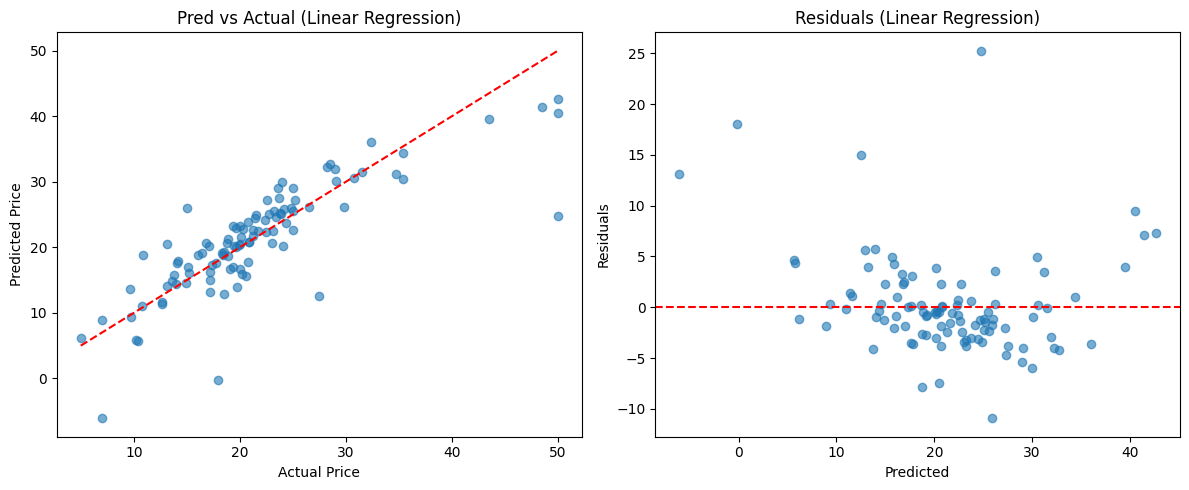

In [86]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_test_pred_l, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Pred vs Actual (Linear Regression)')

plt.subplot(1,2,2)
plt.scatter(y_test_pred_l, y_test - y_test_pred_l, alpha=0.6)
plt.axhline(0, color='r', ls='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals (Linear Regression)')
plt.tight_layout()
plt.show()

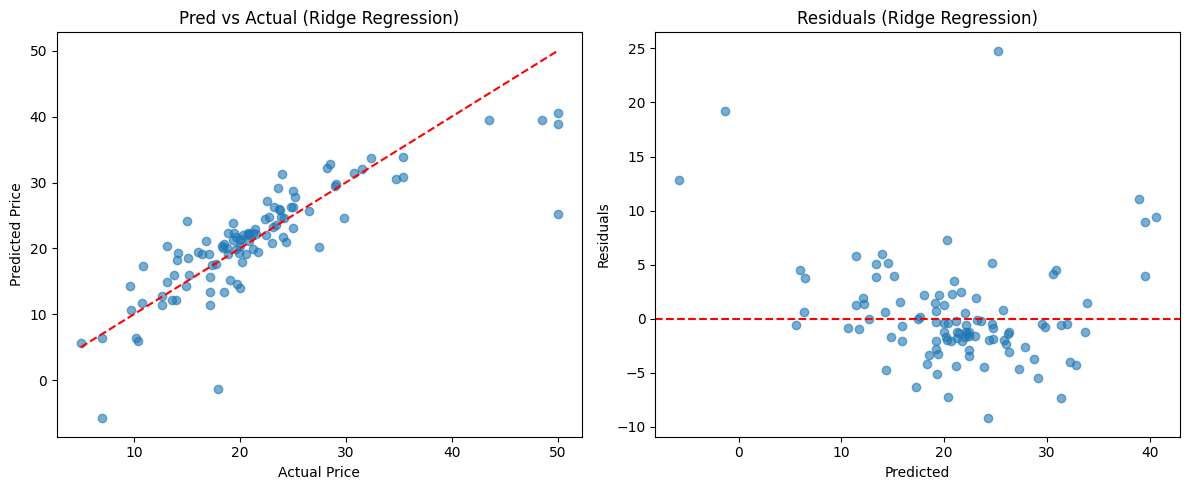

In [88]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_test_pred_r, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Pred vs Actual (Ridge Regression)')

plt.subplot(1,2,2)
plt.scatter(y_test_pred_r, y_test - y_test_pred_r, alpha=0.6)
plt.axhline(0, color='r', ls='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals (Ridge Regression)')
plt.tight_layout()
plt.show()

### Improvements

Train accuracy after log:  0.796504845002159
Test accruacy after log:  0.7452847696576534
Log RMSE: 4.16


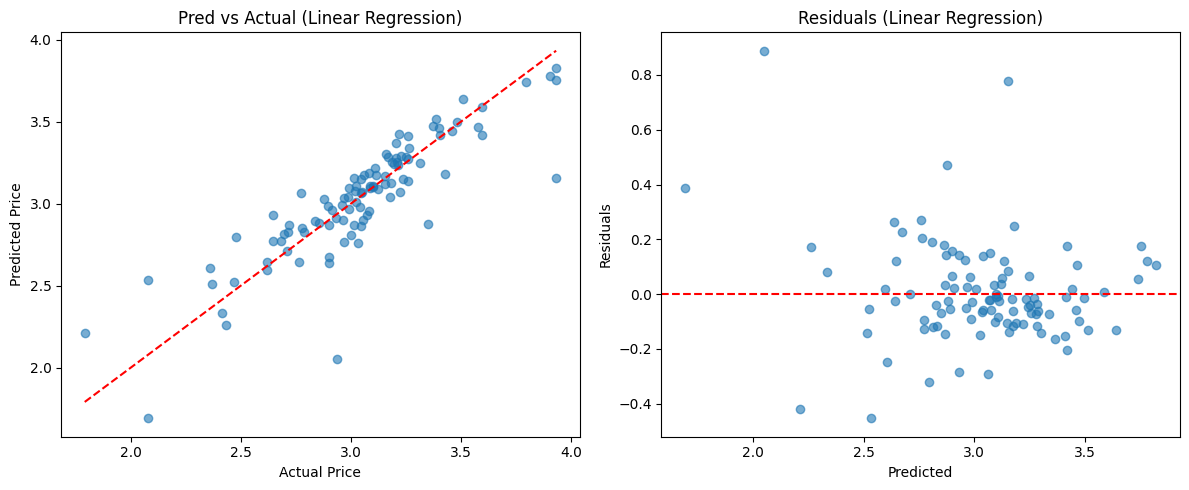

In [99]:
#Log transform of target feature using Linear Regression
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

y_log=np.log1p(df['MEDV'])
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_train, X_test, y_train_log, y_test_log = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)

reg_l_log=LinearRegression().fit(X_train, y_train_log)
y_test_pred_log=reg_l_log.predict(X_test)
print("Train accuracy after log: ", reg_l_log.score(X_train, y_train_log))
print("Test accruacy after log: ", reg_l_log.score(X_test, y_test_log))

#Back transform for evulation
y_test_pred_orig=np.expm1(y_test_pred_log)
rmse_l_log=np.sqrt(mean_squared_error(np.expm1(y_test_log), y_test_pred_orig))
print(f"Log RMSE: {rmse_l_log:.2f}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test_log, y_test_pred_log, alpha=0.6)
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Pred vs Actual (Linear Regression)')

plt.subplot(1,2,2)
plt.scatter(y_test_pred_log, y_test_log - y_test_pred_log, alpha=0.6)
plt.axhline(0, color='r', ls='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals (Linear Regression)')
plt.tight_layout()
plt.show()

In [95]:
#Log transform of target feature using Ridge
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

y_log=np.log1p(df['MEDV'])
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_train, X_test, y_train_log, y_test_log = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)

reg_r_log=RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=6).fit(X_train, y_train_log)
print(f"Best alpha: {ridge_cv.alpha_}")
print(f"Ridge R2: {ridge_cv.score(X_test, y_test):.3f}")
y_test_pred_log=reg_r_log.predict(X_test)
print("Train accuracy after log: ", reg_r_log.score(X_train, y_train_log))
print("Test accruacy after log: ", reg_r_log.score(X_test, y_test_log))

#Back transform for evulation
y_test_pred_orig=np.expm1(y_test_pred_log)
rmse_l_log=np.sqrt(mean_squared_error(np.expm1(y_test_log), y_test_pred_orig))
print(f"Log RMSE: {rmse_l_log:.2f}")

Best alpha: 1.0
Ridge R2: 0.668
Train accuracy after log:  0.7954152319349881
Test accruacy after log:  0.7390293036718563
Log RMSE: 4.24


Training accuracy:  0.9828333326655111
Test accuracy:  0.8062937922587731
Test prediction:  [23.99  29.564 21.704 11.132 20.908 20.912 21.612 20.388 20.618 19.122
  9.116 15.608 15.236  8.178 47.354 33.168 21.432 34.846 25.756 20.918
 23.436 22.006 19.586 24.832 20.57  17.214 18.574 15.75  43.648 18.288
 15.172 17.176 20.538 20.954 22.588 17.794  8.652 28.86  14.044 15.102
 22.892 20.872 22.652 15.472 22.81  22.1   20.974 16.582 14.576 24.84
 16.77  19.038 22.578 39.294 15.006 19.726 19.602 19.286 22.408 20.034
 22.106 21.732 32.894 28.086 18.648 26.532 16.152 18.096 19.478 21.478
 20.048 22.578 24.268 32.202 29.362  8.008 43.104 22.074 22.756 19.824
 26.796 17.948 23.156 43.036 42.256 24.56  22.96  14.83  26.022 16.716
 18.798 12.12  22.744 30.538 21.076 21.598 11.81  23.604 14.942 19.024
 23.748 19.804 28.108 21.232 27.326 20.164  8.284 18.868 21.64  23.148
 34.62  13.874 18.322 18.698 17.414 20.944  9.342 19.688 10.016 46.514
 29.036  9.608 19.604 21.834 21.316 18.34  34.068]
Train 

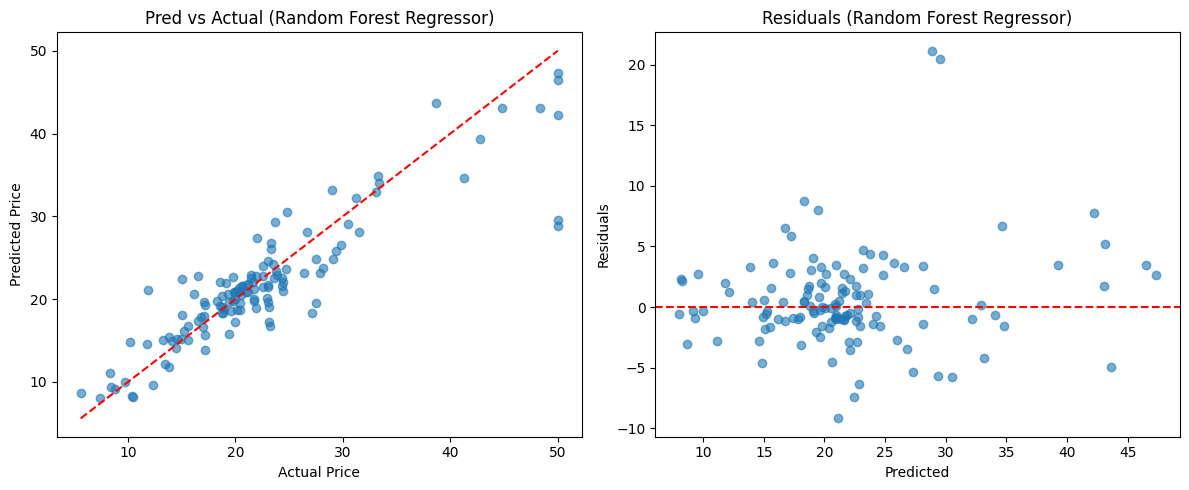

In [9]:
#Using Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X=df.drop('MEDV', axis=1)
y=df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)
tree=RandomForestRegressor(n_estimators=50, random_state=0).fit(X_train, y_train)
y_pred_test=tree.predict(X_test)
y_pred_train=tree.predict(X_train)

print("Training accuracy: ", tree.score(X_train, y_train))
print("Test accuracy: ", tree.score(X_test, y_test))
print("Test prediction: ", tree.predict(X_test))
print("Train RMSE: ", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_test)))

#Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Pred vs Actual (Random Forest Regressor)')

plt.subplot(1,2,2)
plt.scatter(y_pred_test, y_test - y_pred_test, alpha=0.6)
plt.axhline(0, color='r', ls='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals (Random Forest Regressor)')
plt.tight_layout()
plt.show()